In [48]:
from pathlib import Path
import csv
import gzip
import re

import GEOparse
import joblib
import numpy as np
import pandas as pd

DATA_DIR = Path("data")

SERIES_MATRIX_PATH = (
    DATA_DIR / "GSE25055_series_matrix.txt.gz"
)

GPL96_PATH = DATA_DIR / "GPL96.txt"

print("GSE25055 exists:", SERIES_MATRIX_PATH.exists())
print("GPL96 exists:", GPL96_PATH.exists())

print("\nGSE25055 path:")
print(SERIES_MATRIX_PATH.resolve())

print("\nGPL96 path:")
print(GPL96_PATH.resolve())

GSE25055 exists: True
GPL96 exists: True

GSE25055 path:
D:\diplom-project\data\GSE25055_series_matrix.txt.gz

GPL96 path:
D:\diplom-project\data\GPL96.txt


In [49]:
from pathlib import Path
import csv
import gzip
import re

import GEOparse
import joblib
import numpy as np
import pandas as pd

DATA_DIR = Path("data")

SERIES_MATRIX_PATH = (
    DATA_DIR / "GSE25055_series_matrix.txt.gz"
)

GPL96_PATH = DATA_DIR / "GPL96.txt"

print("GSE25055 exists:", SERIES_MATRIX_PATH.exists())
print("GPL96 exists:", GPL96_PATH.exists())

print("\nGSE25055 path:")
print(SERIES_MATRIX_PATH.resolve())

print("\nGPL96 path:")
print(GPL96_PATH.resolve())

GSE25055 exists: True
GPL96 exists: True

GSE25055 path:
D:\diplom-project\data\GSE25055_series_matrix.txt.gz

GPL96 path:
D:\diplom-project\data\GPL96.txt


In [50]:
expression_data = pd.read_csv(
    SERIES_MATRIX_PATH,
    sep="\t",
    comment="!",
    compression="gzip",
    index_col=0
)

print("Original expression shape:", expression_data.shape)

display(
    expression_data.iloc[:10, :5]
)

Original expression shape: (22283, 310)


,GSM615096,GSM615097,GSM615098,GSM615099,GSM615100
ID_REF,,,,,
1007_s_at,12.359267,12.613243,11.551397,11.828700,11.983987
1053_at,8.021741,7.842947,8.776267,9.523877,6.836237
117_at,8.294244,5.474758,8.197121,7.907263,8.625010
121_at,10.840949,11.715159,10.715077,10.750475,10.827725
1255_g_at,7.874062,7.347955,6.523880,6.478643,7.336754
1294_at,8.341292,9.419005,9.297479,8.698516,9.599059
1316_at,8.256335,7.983681,7.820261,7.526617,8.312127
1320_at,6.485966,7.330512,6.423794,7.276040,6.832232
1405_i_at,6.495728,7.332244,10.066291,10.399704,7.090151


In [51]:
expression_data.index = (
    expression_data.index
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
)

expression_data.columns = (
    expression_data.columns
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
)

expression_data.index.name = "PROBEID"

print("First probe IDs:")
print(expression_data.index[:10].tolist())

print("\nFirst patient IDs:")
print(expression_data.columns[:10].tolist())

First probe IDs:
['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at', '1316_at', '1320_at', '1405_i_at', '1431_at']

First patient IDs:
['GSM615096', 'GSM615097', 'GSM615098', 'GSM615099', 'GSM615100', 'GSM615101', 'GSM615102', 'GSM615103', 'GSM615104', 'GSM615105']


In [52]:
X = expression_data.T.copy().astype(float)

X.index.name = "sample_id"
X.columns.name = "PROBEID"

print("Machine-learning matrix:", X.shape)

display(
    X.iloc[:5, :10]
)

Machine-learning matrix: (310, 22283)


PROBEID,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at
sample_id,,,,,,,,,,
GSM615096,12.359267,8.021741,8.294244,10.840949,7.874062,8.341292,8.256335,6.485966,6.495728,7.063123
GSM615097,12.613243,7.842947,5.474758,11.715159,7.347955,9.419005,7.983681,7.330512,7.332244,7.033859
GSM615098,11.551397,8.776267,8.197121,10.715077,6.523880,9.297479,7.820261,6.423794,10.066291,6.661108
GSM615099,11.828700,9.523877,7.907263,10.750475,6.478643,8.698516,7.526617,7.276040,10.399704,6.642930
GSM615100,11.983987,6.836237,8.625010,10.827725,7.336754,9.599059,8.312127,6.832232,7.090151,7.081613


In [53]:
print("Patients:", X.shape[0])
print("Probe features:", X.shape[1])

print("Duplicate patients:", X.index.duplicated().sum())
print("Duplicate probes:", X.columns.duplicated().sum())
print("Missing values:", X.isna().sum().sum())

print(
    "All values finite:",
    np.isfinite(X.to_numpy()).all()
)

assert X.shape == (310, 22283)
assert X.index.is_unique
assert X.columns.is_unique
assert X.isna().sum().sum() == 0
assert np.isfinite(X.to_numpy()).all()

print("\nExpression validation passed.")

Patients: 310
Probe features: 22283
Duplicate patients: 0
Duplicate probes: 0
Missing values: 0
All values finite: True

Expression validation passed.


In [54]:
gpl96 = GEOparse.get_GEO(
    filepath=str(GPL96_PATH),
    silent=True
)

annotation_raw = gpl96.table.copy()

print("Raw annotation shape:", annotation_raw.shape)

print("\nAvailable annotation columns:")
print(annotation_raw.columns.tolist())

display(annotation_raw.head())

Raw annotation shape: (22283, 16)

Available annotation columns:
['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title', 'Gene Symbol', 'ENTREZ_GENE_ID', 'RefSeq Transcript ID', 'Gene Ontology Biological Process', 'Gene Ontology Cellular Component', 'Gene Ontology Molecular Function']


,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...


In [55]:
annotation = annotation_raw[
    [
        "ID",
        "Gene Symbol",
        "Gene Title",
        "ENTREZ_GENE_ID"
    ]
].copy()

annotation = annotation.rename(
    columns={
        "ID": "PROBEID",
        "Gene Symbol": "SYMBOL",
        "Gene Title": "GENENAME",
        "ENTREZ_GENE_ID": "ENTREZID"
    }
)

annotation["PROBEID"] = (
    annotation["PROBEID"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
)

print("Selected annotation shape:", annotation.shape)

display(annotation.head(20))

Selected annotation shape: (22283, 4)


,PROBEID,SYMBOL,GENENAME,ENTREZID
0,1007_s_at,DDR1 /// MIR4640,discoidin domain receptor tyrosine kinase 1 //...,780 /// 100616237
1,1053_at,RFC2,"replication factor C (activator 1) 2, 40kDa",5982
2,117_at,HSPA6,heat shock 70kDa protein 6 (HSP70B'),3310
3,121_at,PAX8,paired box 8,7849
4,1255_g_at,GUCA1A,guanylate cyclase activator 1A (retina),2978
5,1294_at,MIR5193 /// UBA7,microRNA 5193 /// ubiquitin-like modifier acti...,7318 /// 100847079
6,1316_at,THRA,"thyroid hormone receptor, alpha",7067
7,1320_at,PTPN21,"protein tyrosine phosphatase, non-receptor typ...",11099
8,1405_i_at,CCL5,chemokine (C-C motif) ligand 5,6352
9,1431_at,CYP2E1,"cytochrome P450, family 2, subfamily E, polype...",1571


In [56]:
gene_annotation = (
    annotation
    .drop_duplicates(subset="PROBEID")
    .set_index("PROBEID")
    .reindex(X.columns)
    .reset_index()
)

assert len(gene_annotation) == X.shape[1]

assert (
    gene_annotation["PROBEID"].tolist()
    == X.columns.tolist()
)

print(
    "Annotation aligned with X:",
    len(gene_annotation)
)

display(gene_annotation.head(20))

Annotation aligned with X: 22283


,PROBEID,SYMBOL,GENENAME,ENTREZID
0,1007_s_at,DDR1 /// MIR4640,discoidin domain receptor tyrosine kinase 1 //...,780 /// 100616237
1,1053_at,RFC2,"replication factor C (activator 1) 2, 40kDa",5982
2,117_at,HSPA6,heat shock 70kDa protein 6 (HSP70B'),3310
3,121_at,PAX8,paired box 8,7849
4,1255_g_at,GUCA1A,guanylate cyclase activator 1A (retina),2978
5,1294_at,MIR5193 /// UBA7,microRNA 5193 /// ubiquitin-like modifier acti...,7318 /// 100847079
6,1316_at,THRA,"thyroid hormone receptor, alpha",7067
7,1320_at,PTPN21,"protein tyrosine phosphatase, non-receptor typ...",11099
8,1405_i_at,CCL5,chemokine (C-C motif) ligand 5,6352
9,1431_at,CYP2E1,"cytochrome P450, family 2, subfamily E, polype...",1571


In [57]:
symbol_text = (
    gene_annotation["SYMBOL"]
    .fillna("")
    .astype(str)
    .str.strip()
)

missing_mask = symbol_text.eq("")

multiple_mask = symbol_text.str.contains(
    "///",
    regex=False
)

gene_annotation["NUMBER_OF_GENES"] = np.where(
    missing_mask,
    0,
    symbol_text.str.count(r"\s*///\s*") + 1
)

gene_annotation["MAPPING_STATUS"] = np.select(
    [
        missing_mask,
        multiple_mask
    ],
    [
        "No gene symbol",
        "Multiple genes"
    ],
    default="Unique"
)

print("Mapping summary:")

display(
    gene_annotation["MAPPING_STATUS"]
    .value_counts()
    .rename_axis("Mapping status")
    .reset_index(name="Number of probes")
)

display(gene_annotation.head(30))

Mapping summary:


,Mapping status,Number of probes
0,Unique,19820
1,Multiple genes,1405
2,No gene symbol,1058


,PROBEID,SYMBOL,GENENAME,ENTREZID,NUMBER_OF_GENES,MAPPING_STATUS
0,1007_s_at,DDR1 /// MIR4640,discoidin domain receptor tyrosine kinase 1 //...,780 /// 100616237,2,Multiple genes
1,1053_at,RFC2,"replication factor C (activator 1) 2, 40kDa",5982,1,Unique
2,117_at,HSPA6,heat shock 70kDa protein 6 (HSP70B'),3310,1,Unique
3,121_at,PAX8,paired box 8,7849,1,Unique
4,1255_g_at,GUCA1A,guanylate cyclase activator 1A (retina),2978,1,Unique
5,1294_at,MIR5193 /// UBA7,microRNA 5193 /// ubiquitin-like modifier acti...,7318 /// 100847079,2,Multiple genes
6,1316_at,THRA,"thyroid hormone receptor, alpha",7067,1,Unique
7,1320_at,PTPN21,"protein tyrosine phosphatase, non-receptor typ...",11099,1,Unique
8,1405_i_at,CCL5,chemokine (C-C motif) ligand 5,6352,1,Unique
9,1431_at,CYP2E1,"cytochrome P450, family 2, subfamily E, polype...",1571,1,Unique


In [58]:
def find_gene(symbol):
    symbol = symbol.upper().strip()

    result = gene_annotation[
        gene_annotation["SYMBOL"]
        .fillna("")
        .str.split(r"\s*///\s*")
        .apply(
            lambda values: symbol in [
                value.upper()
                for value in values
            ]
        )
    ]

    return result


display(find_gene("BRCA1"))

,PROBEID,SYMBOL,GENENAME,ENTREZID,NUMBER_OF_GENES,MAPPING_STATUS
4057,204531_s_at,BRCA1,"breast cancer 1, early onset",672,1,Unique
11244,211851_x_at,BRCA1,"breast cancer 1, early onset",672,1,Unique


In [59]:
with gzip.open(
    SERIES_MATRIX_PATH,
    mode="rt",
    encoding="utf-8"
) as file:
    metadata_lines = file.readlines()

print("Metadata and data lines read:", len(metadata_lines))

Metadata and data lines read: 22374


In [60]:
def parse_geo_metadata_line(line):
    parsed = next(
        csv.reader(
            [line],
            delimiter="\t",
            quotechar='"'
        )
    )

    return parsed[1:]


sample_lines = [
    line
    for line in metadata_lines
    if line.startswith("!Sample_geo_accession")
]

response_lines = [
    line
    for line in metadata_lines
    if (
        line.startswith("!Sample_characteristics")
        and "pathologic_response_pcr_rd" in line.lower()
    )
]

print("Sample-ID lines found:", len(sample_lines))
print("Response lines found:", len(response_lines))

assert len(sample_lines) == 1
assert len(response_lines) == 1

metadata_sample_ids = parse_geo_metadata_line(
    sample_lines[0]
)

response_values = parse_geo_metadata_line(
    response_lines[0]
)

response_values = [
    re.sub(
        r"^pathologic_response_pcr_rd:\s*",
        "",
        value,
        flags=re.IGNORECASE
    ).strip()
    for value in response_values
]

print("Patient IDs:", len(metadata_sample_ids))
print("Response values:", len(response_values))
print("Unique responses:", sorted(set(response_values)))

Sample-ID lines found: 1
Response lines found: 1
Patient IDs: 310
Response values: 310
Unique responses: ['NA', 'RD', 'pCR']


In [61]:
clinical_outcome = pd.DataFrame({
    "Patient": metadata_sample_ids,
    "Treatment_Response": response_values
})

clinical_outcome["Response_Label"] = (
    clinical_outcome["Treatment_Response"]
    .str.strip()
    .str.upper()
    .map({
        "PCR": 1,
        "RD": 0
    })
)

display(clinical_outcome.head(20))

print("\nClinical table shape:")
print(clinical_outcome.shape)

print("\nResponse distribution:")
print(
    clinical_outcome["Treatment_Response"]
    .value_counts(dropna=False)
)

print("\nNumeric label distribution:")
print(
    clinical_outcome["Response_Label"]
    .value_counts(dropna=False)
    .sort_index()
)

,Patient,Treatment_Response,Response_Label
0,GSM615096,RD,0.0
1,GSM615097,RD,0.0
2,GSM615098,RD,0.0
3,GSM615099,pCR,1.0
4,GSM615100,RD,0.0
5,GSM615101,RD,0.0
6,GSM615102,RD,0.0
7,GSM615103,RD,0.0
8,GSM615104,RD,0.0
9,GSM615105,NA,NaN



Clinical table shape:
(310, 3)

Response distribution:
Treatment_Response
RD     249
pCR     57
NA       4
Name: count, dtype: int64

Numeric label distribution:
Response_Label
0.0    249
1.0     57
NaN      4
Name: count, dtype: int64


In [62]:
assert clinical_outcome["Patient"].is_unique

assert (
    clinical_outcome["Response_Label"]
    .notna()
    .all()
)

clinical_by_patient = (
    clinical_outcome
    .set_index("Patient")
)

missing_patients = X.index.difference(
    clinical_by_patient.index
)

extra_patients = clinical_by_patient.index.difference(
    X.index
)

print(
    "Expression patients without response:",
    len(missing_patients)
)

print(
    "Response patients without expression:",
    len(extra_patients)
)

assert len(missing_patients) == 0
assert len(extra_patients) == 0

clinical_aligned = clinical_by_patient.reindex(
    X.index
)

y = clinical_aligned[
    "Response_Label"
].astype("int64")

y.name = "pCR"

AssertionError: 

In [63]:
patients_without_response = clinical_outcome[
    clinical_outcome["Response_Label"].isna()
].copy()

print(
    "Patients without known treatment response:",
    len(patients_without_response)
)

display(patients_without_response)

Patients without known treatment response: 4


,Patient,Treatment_Response,Response_Label
9,GSM615105,NA,NaN
22,GSM615118,NA,NaN
23,GSM615119,NA,NaN
67,GSM615163,NA,NaN


In [64]:
# Patient IDs in the clinical table must be unique
assert clinical_outcome["Patient"].is_unique


# Use patient ID as the index
clinical_by_patient = (
    clinical_outcome
    .set_index("Patient")
)


# First verify that all 310 expression patients
# have a corresponding clinical metadata row
missing_clinical_rows = X.index.difference(
    clinical_by_patient.index
)

extra_clinical_rows = clinical_by_patient.index.difference(
    X.index
)

print(
    "Expression patients without clinical metadata:",
    len(missing_clinical_rows)
)

print(
    "Clinical patients without expression data:",
    len(extra_clinical_rows)
)

assert len(missing_clinical_rows) == 0
assert len(extra_clinical_rows) == 0


# Reorder the clinical table to match X exactly
clinical_aligned = clinical_by_patient.reindex(
    X.index
)


# Preserve the complete 310-patient expression matrix
X_all = X.copy()


# Identify patients with a known pCR/RD outcome
known_response_mask = (
    clinical_aligned["Response_Label"].notna()
)


# Store the excluded patients for documentation
excluded_patients = clinical_aligned[
    ~known_response_mask
].copy()


# Keep only labelled patients for supervised ML
X = X_all.loc[known_response_mask].copy()

y = (
    clinical_aligned
    .loc[known_response_mask, "Response_Label"]
    .astype("int64")
)

y.name = "pCR"


print("\nPatients excluded because response is NA:")
display(excluded_patients)

print("Complete expression matrix:", X_all.shape)
print("ML expression matrix:", X.shape)
print("Target vector:", y.shape)

Expression patients without clinical metadata: 0
Clinical patients without expression data: 0

Patients excluded because response is NA:


,Treatment_Response,Response_Label
sample_id,,
GSM615105,NA,NaN
GSM615118,NA,NaN
GSM615119,NA,NaN
GSM615163,NA,NaN


Complete expression matrix: (310, 22283)
ML expression matrix: (306, 22283)
Target vector: (306,)


In [65]:
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts().sort_index())

print(
    "\nPatient order aligned:",
    X.index.equals(y.index)
)

print(
    "Missing expression values:",
    X.isna().sum().sum()
)

print(
    "Missing response labels:",
    y.isna().sum()
)

print(
    "Duplicate patients:",
    X.index.duplicated().sum()
)

print(
    "Duplicate probes:",
    X.columns.duplicated().sum()
)


assert X.shape == (306, 22283)
assert y.shape == (306,)

assert X.index.equals(y.index)

assert X.index.is_unique
assert X.columns.is_unique

assert X.isna().sum().sum() == 0
assert y.isna().sum() == 0

assert set(y.unique()) == {0, 1}

assert (y == 0).sum() == 249
assert (y == 1).sum() == 57

print("\nEverything is ready for LASSO.")

Final X shape: (306, 22283)
Final y shape: (306,)

Class distribution:
pCR
0    249
1     57
Name: count, dtype: int64

Patient order aligned: True
Missing expression values: 0
Missing response labels: 0
Duplicate patients: 0
Duplicate probes: 0

Everything is ready for LASSO.


In [66]:
shape_before = X.shape
labels_before = y.value_counts().to_dict()

joblib.dump(
    {
        "X": X,
        "y": y,
        "gene_annotation": gene_annotation,
        "clinical_outcome": clinical_outcome
    },
    checkpoint_path,
    compress=3
)

print(X.shape == shape_before)
print(y.value_counts().to_dict() == labels_before)

NameError: name 'checkpoint_path' is not defined

In [67]:
from pathlib import Path
import joblib

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

checkpoint_path = (
    DATA_DIR / "GSE25055_pre_lasso.joblib"
)

# Record the state before saving
shape_before = X.shape
labels_before = y.value_counts().to_dict()

# Save the checkpoint
joblib.dump(
    {
        "X": X,
        "y": y,
        "gene_annotation": gene_annotation,
        "clinical_outcome": clinical_outcome
    },
    checkpoint_path,
    compress=3
)

# Verify that saving did not modify X or y
print(
    "X unchanged:",
    X.shape == shape_before
)

print(
    "y unchanged:",
    y.value_counts().to_dict() == labels_before
)

print("\nCheckpoint saved:")
print(checkpoint_path.resolve())

X unchanged: True
y unchanged: True

Checkpoint saved:
D:\diplom-project\data\GSE25055_pre_lasso.joblib


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42

assert len(X) == len(y)
assert X.index.equals(y.index)
assert X.isna().sum().sum() == 0
assert y.isna().sum() == 0
assert set(y.unique()) == {0, 1}

print("X:", X.shape)
print("y:", y.shape)
print("\nClass distribution:")
print(y.value_counts().sort_index())

X: (306, 22283)
y: (306,)

Class distribution:
pCR
0    249
1     57
Name: count, dtype: int64


,Percentile,Expression_value
0,0.0,-3.521816
1,0.1,1.185961
2,1.0,2.657232
3,25.0,6.545943
4,50.0,8.183030
5,75.0,9.489884
6,99.0,14.058716
7,99.9,16.094967
8,100.0,19.990487


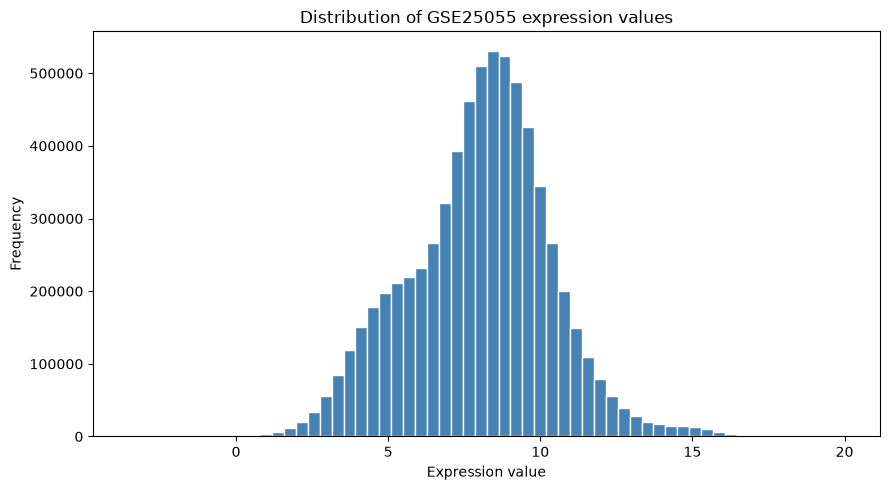

In [69]:
values = X.to_numpy(dtype=float)

percentiles = [0, 0.1, 1, 25, 50, 75, 99, 99.9, 100]

scale_summary = pd.DataFrame({
    "Percentile": percentiles,
    "Expression_value": np.percentile(
        values,
        percentiles
    )
})

display(scale_summary)

plt.figure(figsize=(9, 5))

plt.hist(
    values.ravel(),
    bins=60,
    color="steelblue",
    edgecolor="white"
)

plt.xlabel("Expression value")
plt.ylabel("Frequency")
plt.title("Distribution of GSE25055 expression values")
plt.tight_layout()
plt.show()

In [70]:
minimum_position = np.unravel_index(
    np.argmin(values),
    values.shape
)

maximum_position = np.unravel_index(
    np.argmax(values),
    values.shape
)

minimum_patient = X.index[
    minimum_position[0]
]

minimum_probe = X.columns[
    minimum_position[1]
]

maximum_patient = X.index[
    maximum_position[0]
]

maximum_probe = X.columns[
    maximum_position[1]
]

print("Minimum:")
print("Patient:", minimum_patient)
print("Probe:", minimum_probe)
print("Value:", X.loc[minimum_patient, minimum_probe])

print("\nMaximum:")
print("Patient:", maximum_patient)
print("Probe:", maximum_probe)
print("Value:", X.loc[maximum_patient, maximum_probe])

Minimum:
Patient: GSM615239
Probe: 220656_at
Value: -3.521816088

Maximum:
Patient: GSM615110
Probe: AFFX-r2-P1-cre-3_at
Value: 19.99048748


In [71]:
negative_count = (X < 0).sum().sum()

negative_percentage = (
    negative_count / X.size
) * 100

print("Negative values:", negative_count)

print(
    "Percentage of all values:",
    negative_percentage
)

Negative values: 764
Percentage of all values: 0.011204649401533864


In [72]:
display(
    gene_annotation[
        gene_annotation["PROBEID"]
        == minimum_probe
    ]
)

,PROBEID,SYMBOL,GENENAME,ENTREZID,NUMBER_OF_GENES,MAPPING_STATUS
20019,220656_at,NaN,NaN,NaN,0,No gene symbol


In [73]:
print("Minimum patient:", minimum_patient)
print("Minimum probe:", minimum_probe)
print(
    "Minimum value:",
    X.loc[minimum_patient, minimum_probe]
)

print("\nTen lowest values for this probe:")

display(
    X[minimum_probe]
    .sort_values()
    .head(10)
    .to_frame("Expression_value")
)

print("\nDistribution of this probe:")

display(
    X[minimum_probe]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.50,
            0.95,
            0.99
        ]
    )
)

Minimum patient: GSM615239
Minimum probe: 220656_at
Minimum value: -3.521816088

Ten lowest values for this probe:


,Expression_value
sample_id,
GSM615239,-3.521816
GSM615403,-3.418710
GSM615147,-3.077750
GSM615281,-1.901000
GSM615264,-1.008272
GSM615286,-0.936822
GSM615220,-0.491859
GSM615261,-0.462633
GSM615203,-0.449090



Distribution of this probe:


count    306.000000
mean       3.864455
std        1.901736
min       -3.521816
1%        -1.856364
5%         0.757168
50%        4.372713
95%        6.114833
99%        6.456099
max        7.635792
Name: 220656_at, dtype: float64

In [74]:
negative_count = int(
    (X < 0).sum().sum()
)

negative_percentage = (
    negative_count / X.size
) * 100

print("Negative values:", negative_count)

print(
    "Percentage of all expression values:",
    f"{negative_percentage:.8f}%"
)

Negative values: 764
Percentage of all expression values: 0.01120465%


In [75]:
from datetime import datetime, timezone
from pathlib import Path
import joblib

DATA_DIR = Path("data")

checkpoint_path = (
    DATA_DIR / "GSE25055_pre_lasso.joblib"
)

checkpoint = {
    "dataset_id": "GSE25055",
    "checkpoint_version": 1,
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "label_mapping": {
        "RD": 0,
        "pCR": 1
    },

    "number_of_original_patients": len(
        clinical_outcome
    ),

    "number_of_modeling_patients": len(X),

    "X": X,
    "y": y,
    "gene_annotation": gene_annotation,
    "clinical_outcome": clinical_outcome
}

joblib.dump(
    checkpoint,
    checkpoint_path,
    compress=3
)

print("Checkpoint saved:")
print(checkpoint_path.resolve())

print(
    "File exists:",
    checkpoint_path.exists()
)

print(
    "File size in MB:",
    round(
        checkpoint_path.stat().st_size
        / (1024 ** 2),
        2
    )
)

Checkpoint saved:
D:\diplom-project\data\GSE25055_pre_lasso.joblib
File exists: True
File size in MB: 49.3
